In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("merged.csv")

In [3]:
data.head()

,credit_score,oldest_credit_line_age,oldest_account_age_months,num_delinquencies_2yrs,num_public_records,num_collections,num_credit_accounts,total_credit_limit,num_inquiries_6mo,recent_inquiry_count,...,application_period_morning,application_period_night,login_activity_level_low,login_activity_level_medium,login_activity_level_high,calls_level_high,calls_level_low,application_period_evening.1,application_period_morning.1,application_period_night.1
0,696,22.0,264.0,0.0,1,0,14,169100.0,2,2,...,0,0,0,1,0,0,1,0,0,0
1,659,3.5,42.0,0.0,0,0,13,78200.0,5,5,...,0,0,1,0,0,0,1,0,0,0
2,662,0.0,0.0,0.0,0,0,3,41400.0,2,2,...,0,1,1,0,0,0,1,0,0,1
3,676,9.0,108.0,0.0,0,0,8,60000.0,1,1,...,0,1,1,0,0,0,1,0,0,1
4,678,8.0,96.0,0.0,0,0,7,49700.0,1,1,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
data.columns

Index(['credit_score', 'oldest_credit_line_age', 'oldest_account_age_months',
       'num_delinquencies_2yrs', 'num_public_records', 'num_collections',
       'num_credit_accounts', 'total_credit_limit', 'num_inquiries_6mo',
       'recent_inquiry_count', 'account_diversity_index',
       'total_delinquencies', 'credit_utilization_ratio',
       'recent_inquiry_ratio', 'total_recent_inquiries', 'id', 'age',
       'annual_income', 'employment_length', 'education', 'marital_status',
       'num_dependents', 'age_group', 'employment_length_group',
       'dependents_level', 'employment_type_clean_full_time',
       'employment_type_clean_part_time',
       'employment_type_clean_self_employed', 'monthly_income',
       'existing_monthly_debt', 'monthly_payment', 'debt_to_income_ratio',
       'debt_service_ratio', 'payment_to_income_ratio', 'credit_utilization',
       'credit_usage_amount', 'available_credit', 'total_monthly_debt_payment',
       'loan_to_annual_income', 'total_debt_amo

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89999 entries, 0 to 89998
Data columns (total 91 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   credit_score                         89999 non-null  int64  
 1   oldest_credit_line_age               89999 non-null  float64
 2   oldest_account_age_months            89999 non-null  float64
 3   num_delinquencies_2yrs               89999 non-null  float64
 4   num_public_records                   89999 non-null  int64  
 5   num_collections                      89999 non-null  int64  
 6   num_credit_accounts                  89999 non-null  int64  
 7   total_credit_limit                   89999 non-null  float64
 8   num_inquiries_6mo                    89999 non-null  int64  
 9   recent_inquiry_count                 89999 non-null  int64  
 10  account_diversity_index              89999 non-null  float64
 11  total_delinquencies         

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
import numpy as np

# Dataset
df = pd.read_csv("merged.csv")

# Target va features
target_col = 'default'
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1, errors='ignore')
y = df[target_col]

# Numerical ustunlar
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Categorical ustunlar
categorical_cols = [col for col in X.columns if col not in numerical_cols]

# 1️⃣ Missing values to'ldirish
X[numerical_cols] = SimpleImputer(strategy='mean').fit_transform(X[numerical_cols])
X[categorical_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[categorical_cols])

# 2️⃣ Categorical indekslari (SMOTENC)
categorical_idx = [X.columns.get_loc(col) for col in categorical_cols]

# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4️⃣ SMOTENC bilan balanslash
smote = SMOTENC(categorical_features=categorical_idx, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 5️⃣ Model ro'yxati
models = {
    "RandomForest": RandomForestClassifier(n_estimators=500, max_depth=7, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# 6️⃣ Har bir modelni o'qitish va ROC-AUC baholash
for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "LightGBM":
        model.fit(
            X_train_bal, y_train_bal,
            eval_set=[(X_test, y_test)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
        )
    else:
        model.fit(X_train_bal, y_train_bal)

    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"{name} ROC-AUC: {roc_auc:.4f}")

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], linestyle='--', color='red')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['age_group' 'employment_length_group' 'dependents_level']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


ValueError: Columns must be same length as key

Numerical: 83, Categorical: 2

Training RandomForest...
RandomForest ROC-AUC: 0.7634


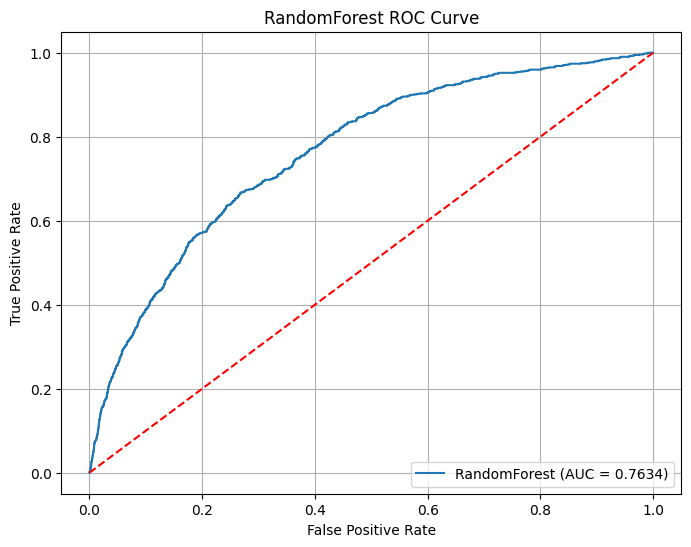


Training LightGBM...
[LightGBM] [Info] Number of positive: 68324, number of negative: 68324
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21211
[LightGBM] [Info] Number of data points in the train set: 136648, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.789176	valid_0's binary_logloss: 0.221622
[100]	valid_0's auc: 0.801254	valid_0's binary_logloss: 0.173947
[150]	valid_0's auc: 0.805133	valid_0's binary_logloss: 0.167694
[200]	valid_0's auc: 0.806247	valid_0's binary_logloss: 0.166477
Early stopping, best iteration is:
[183]	valid_0's auc: 0.807105	valid_0's binary_logloss: 0.166511
LightGBM ROC-AUC: 0.8071


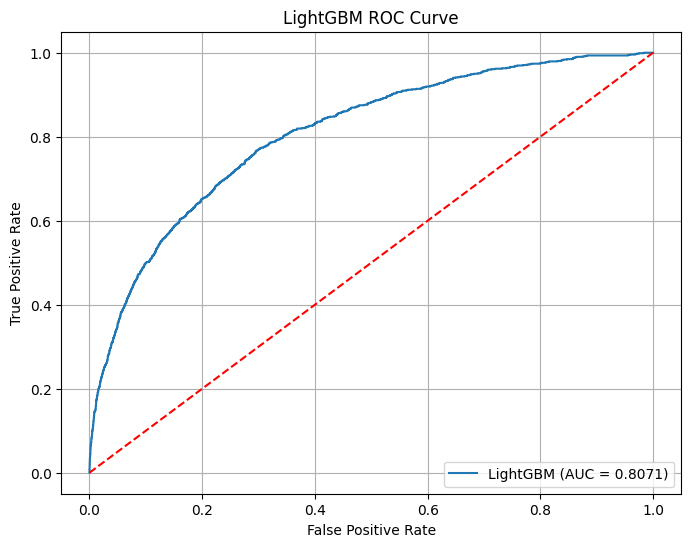


Training XGBoost...


c:\Users\behru\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:59:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC: 0.7832


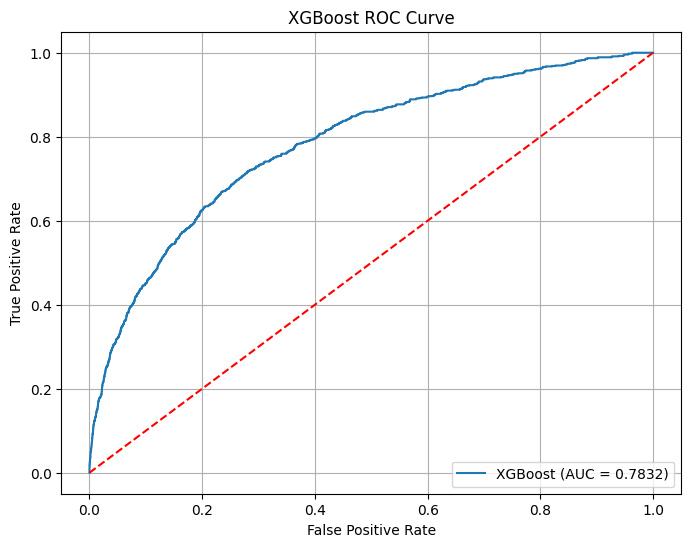

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt

# 1️⃣ Datasetni o'qish
df = pd.read_csv("merged.csv")

# 2️⃣ Target va features
target_col = 'default'
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1, errors='ignore')
y = df[target_col]

# 3️⃣ Numerical va categorical ustunlar
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# 4️⃣ Faqat haqiqatan mavjud ustunlar va NaN ustunlarini olib tashlash
numerical_cols = [col for col in numerical_cols if col in X.columns and X[col].notna().sum() > 0]
categorical_cols = [col for col in categorical_cols if col in X.columns and X[col].notna().sum() > 0]

print(f"Numerical: {len(numerical_cols)}, Categorical: {len(categorical_cols)}")

# 5️⃣ Missing values to'ldirish
if numerical_cols:
    X_num = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X[numerical_cols]),
                         columns=numerical_cols, index=X.index)
else:
    X_num = pd.DataFrame(index=X.index)

if categorical_cols:
    X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X[categorical_cols]),
                         columns=categorical_cols, index=X.index)
else:
    X_cat = pd.DataFrame(index=X.index)

# 6️⃣ One-Hot Encoding categorical ustunlar
if categorical_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = pd.DataFrame(ohe.fit_transform(X_cat),
                             columns=ohe.get_feature_names_out(categorical_cols),
                             index=X.index)
else:
    X_encoded = pd.DataFrame(index=X.index)

# 7️⃣ Yakuniy feature set
X_final = pd.concat([X_num, X_encoded], axis=1)

# 8️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# 9️⃣ SMOTENC bilan balanslash
categorical_idx = [X_final.columns.get_loc(col) for col in X_encoded.columns] if not X_encoded.empty else []
if categorical_idx:
    smote = SMOTENC(categorical_features=categorical_idx, random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
else:
    X_train_bal, y_train_bal = X_train, y_train

# 🔟 Model ro'yxati
models = {
    "RandomForest": RandomForestClassifier(n_estimators=500, max_depth=7, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7,
                                 random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# 1️⃣1️⃣ Har bir modelni o'qitish va AUC baholash
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name == "LightGBM":
        model.fit(X_train_bal, y_train_bal, eval_set=[(X_test, y_test)],
                  eval_metric='auc', callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)])
    else:
        model.fit(X_train_bal, y_train_bal)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"{name} ROC-AUC: {roc_auc:.4f}")
    
    # ROC curve chizish
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], linestyle='--', color='red')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()



Training RandomForest...
RandomForest ROC-AUC: 0.7967


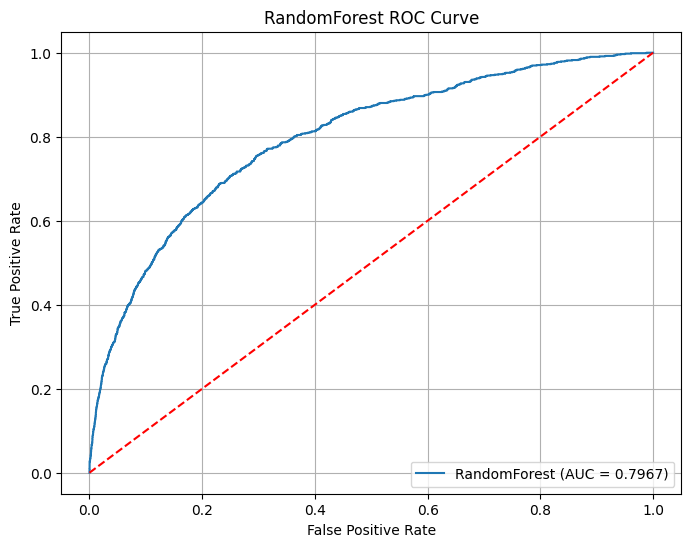


Training SVM...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# 1️⃣ Datasetni o'qish
df = pd.read_csv("merged.csv")

# 2️⃣ Target va features
target_col = 'default'
X = df.drop([target_col, 'id', 'previous_zip_code'], axis=1, errors='ignore')
y = df[target_col]

# 3️⃣ Numerical va categorical ustunlar
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# Faqat haqiqatan mavjud va NaN ustunlarini olib tashlash
numerical_cols = [col for col in numerical_cols if col in X.columns and X[col].notna().sum() > 0]
categorical_cols = [col for col in categorical_cols if col in X.columns and X[col].notna().sum() > 0]

# 4️⃣ Missing values to'ldirish
X_num = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X[numerical_cols]),
                     columns=numerical_cols, index=X.index)

if categorical_cols:
    X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X[categorical_cols]),
                         columns=categorical_cols, index=X.index)
else:
    X_cat = pd.DataFrame(index=X.index)

# 5️⃣ One-Hot Encoding categorical ustunlar
if categorical_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_encoded = pd.DataFrame(ohe.fit_transform(X_cat),
                             columns=ohe.get_feature_names_out(categorical_cols),
                             index=X.index)
else:
    X_encoded = pd.DataFrame(index=X.index)

# 6️⃣ Featurelarni birlashtirish
X_final = pd.concat([X_num, X_encoded], axis=1)

# 7️⃣ Numerical ustunlarni standartlashtirish SVM uchun
scaler = StandardScaler()
X_final_scaled = pd.DataFrame(scaler.fit_transform(X_final), columns=X_final.columns, index=X_final.index)

# 8️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 9️⃣ Model ro'yxati
models = {
    "RandomForest": RandomForestClassifier(n_estimators=500, max_depth=7, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

# 🔟 Modelni o'qitish va ROC-AUC baholash
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"{name} ROC-AUC: {roc_auc:.4f}")
    
    # ROC curve chizish
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], linestyle='--', color='red')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
